In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
!ls /kaggle/input/

datasets


In [5]:
!ls /kaggle/input/datasets/

banuprasadb


In [6]:
!ls /kaggle/input/datasets/banuprasadb/

visdrone-dataset


In [7]:
!ls /kaggle/input/datasets/banuprasadb/visdrone-dataset/

VisDrone_Dataset


In [8]:
!ls /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/

VisDrone2019-DET-test-challenge  VisDrone2019-DET-train  visdrone.yaml
VisDrone2019-DET-test-dev	 VisDrone2019-DET-val


In [9]:
!ls /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-train/

images	labels


In [10]:
!cat /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/visdrone.yaml

# VisDrone Dataset Configuration
path: ./VisDrone_Dataset
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images
test: VisDrone2019-DET-test-dev/images

#number of classes
nc: 10

# Class names
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor


In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.8 MB/s eta 0:00:00


In [17]:
import yaml

config = {
    'path': '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset',
    'train': 'VisDrone2019-DET-train/images',
    'val': 'VisDrone2019-DET-val/images',
    'test': 'VisDrone2019-DET-test-dev/images',
    'nc': 10,
    'names': {
        0: 'pedestrian', 1: 'people', 2: 'bicycle',
        3: 'car', 4: 'van', 5: 'truck', 6: 'tricycle',
        7: 'awning-tricycle', 8: 'bus', 9: 'motor'
    }
}

with open('/kaggle/working/visdrone.yaml', 'w') as f:
    yaml.dump(config, f)
print("Done!")

Done!


In [18]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')
model.train(
    data='/kaggle/working/visdrone.yaml',
    epochs=50,
    imgsz=960,
    batch=8,
    patience=10,
    workers=4,
    project='/kaggle/working/drone_detection',
    name='train',
    device=0
)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/visdrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, pe

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a6265a0f3e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [20]:
from ultralytics import YOLO

model = YOLO('/kaggle/working/drone_detection/train-4/weights/best.pt')
metrics = model.val(data='/kaggle/working/visdrone.yaml', verbose=False)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 228.7±100.9 MB/s, size: 153.1 KB)
val: Scanning /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/labels... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 678.6it/s 0.8s<0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.4it/s 14.4s0.3s
                   all        548      38759      0.589      0.472      0.478      0.289
Speed: 1.7ms preprocess, 11.9ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val


In [21]:
print(f"\n{'Class':<20} {'mAP@0.5':>10} {'Precision':>10} {'Recall':>10}")
print("-" * 55)

for i, name in model.names.items():
    class_map50 = metrics.box.ap50[i]
    class_prec = metrics.box.p[i]
    class_rec = metrics.box.r[i]
    print(f"{name:<20} {class_map50:>10.3f} {class_prec:>10.3f} {class_rec:>10.3f}")

print("-" * 55)
print(f"{'Overall Average':<20} {metrics.box.map50:>10.3f} {metrics.box.mp:>10.3f} {metrics.box.mr:>10.3f}")


Class                   mAP@0.5  Precision     Recall
-------------------------------------------------------
pedestrian                0.559      0.642      0.530
people                    0.424      0.631      0.406
bicycle                   0.249      0.416      0.265
car                       0.846      0.785      0.829
van                       0.507      0.587      0.510
truck                     0.458      0.559      0.452
tricycle                  0.381      0.506      0.399
awning-tricycle           0.189      0.377      0.239
bus                       0.605      0.767      0.525
motor                     0.564      0.618      0.565
-------------------------------------------------------
Overall Average           0.478      0.589      0.472


Image 0: Humans=4
Image 1: Humans=8
Image 2: Humans=3
Image 3: Humans=1
Image 4: Humans=0


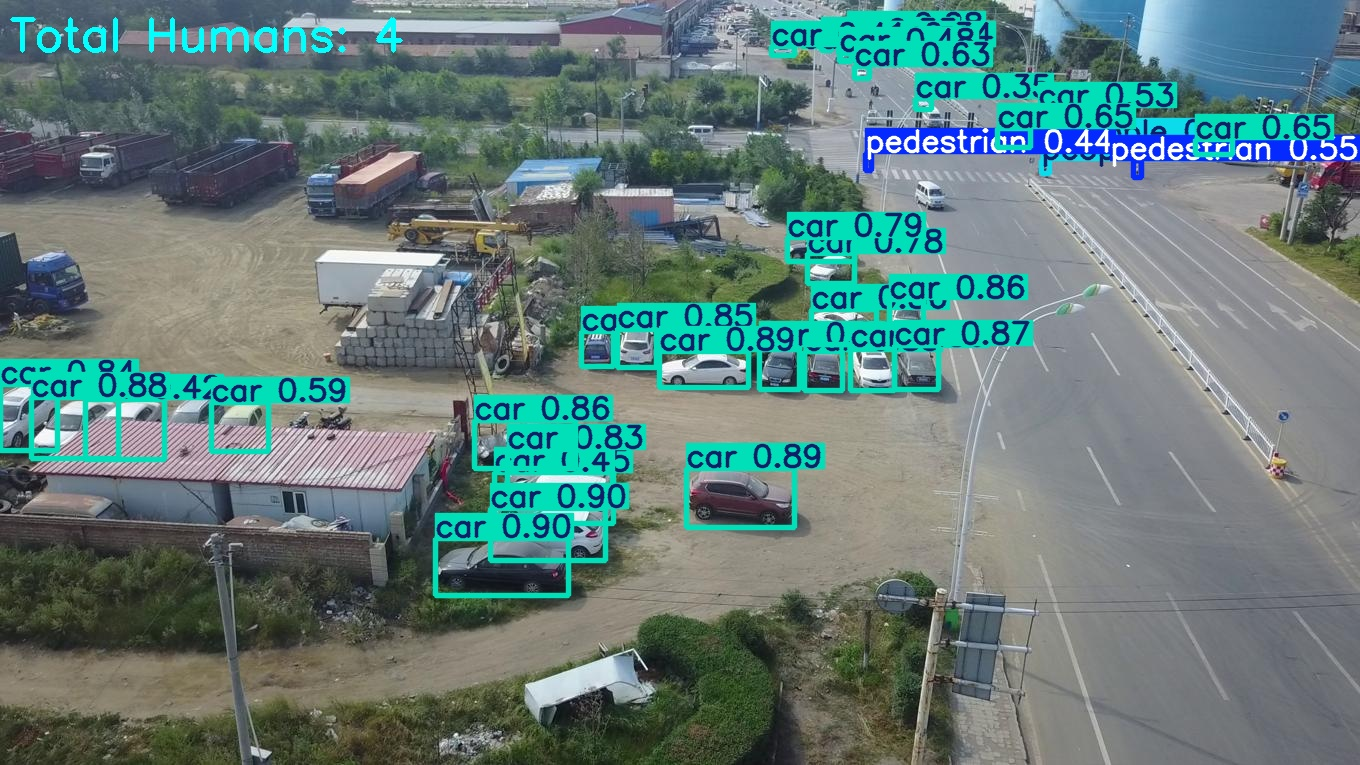

In [43]:
import cv2
import glob
from IPython.display import Image as IPImage


test_images = sorted(glob.glob('/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/images/*.jpg'))

for i, img_path in enumerate(test_images[:5]):
    results = model.predict(source=img_path, classes=[0, 1, 3], conf=0.25, verbose=False)
    
    for r in results:
        class_ids = r.boxes.cls.tolist()
        human_count = sum(1 for c in class_ids if c in [0, 1])
        
        img = r.plot()
        cv2.putText(img, f'Total Humans: {human_count}', (10, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 3)
        
        out_path = f'/kaggle/working/result_{i}.jpg'
        cv2.imwrite(out_path, img)
        print(f"Image {i}: Humans={human_count}")

IPImage('/kaggle/working/result_0.jpg')

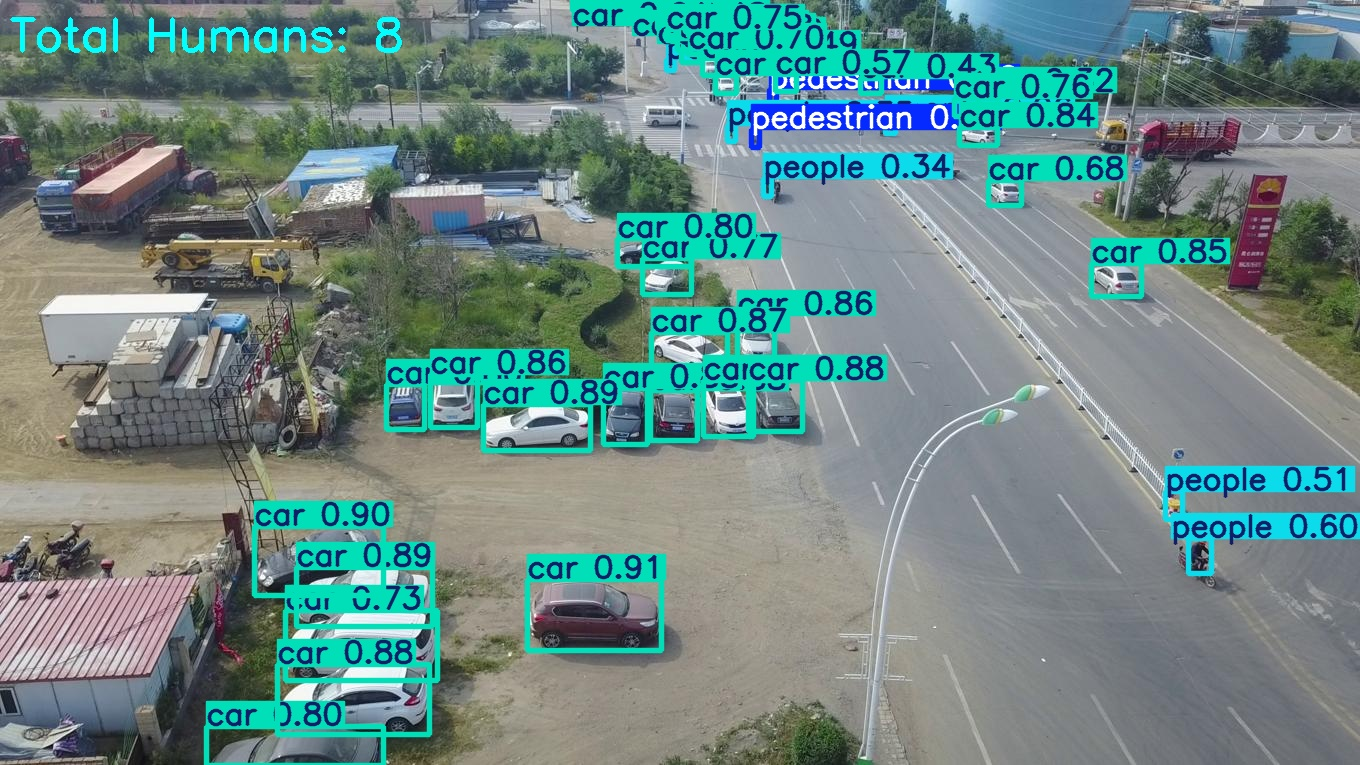

In [44]:
IPImage('/kaggle/working/result_1.jpg')

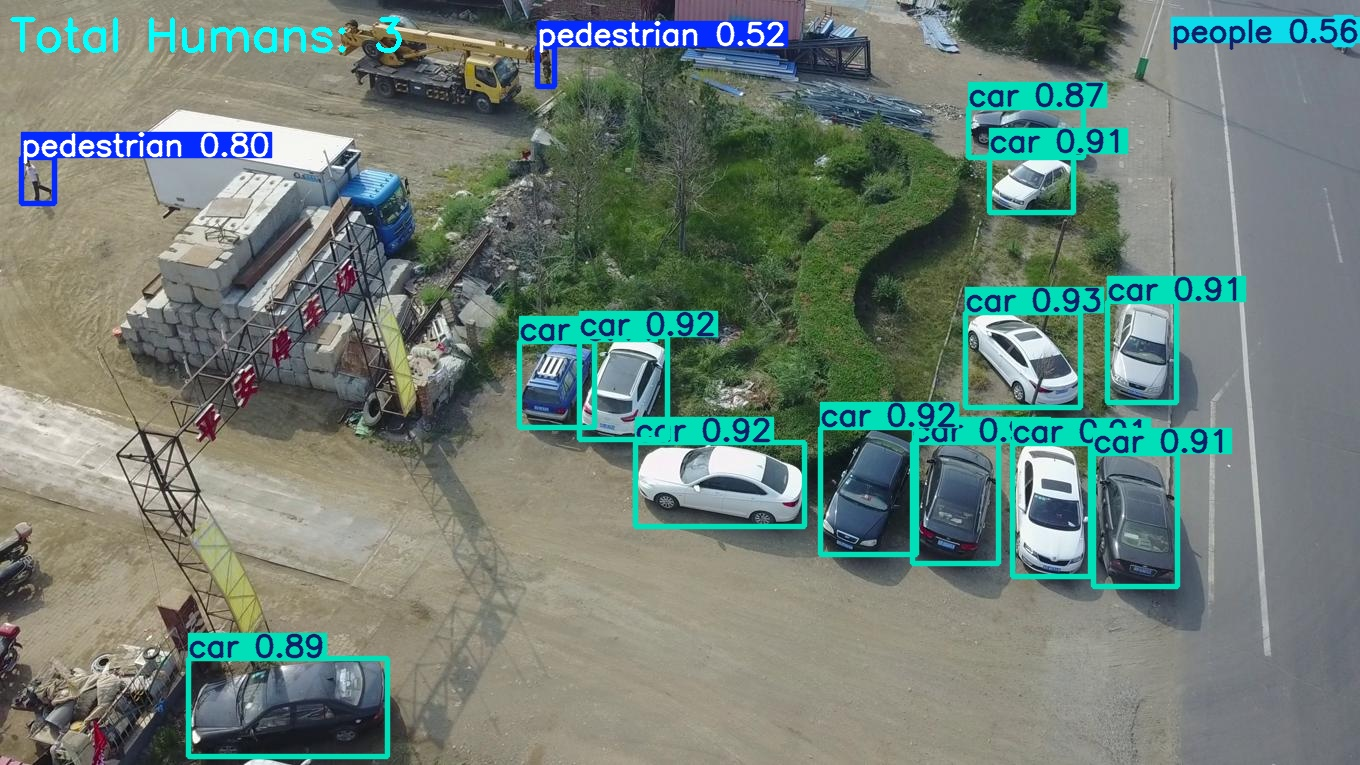

In [45]:
IPImage('/kaggle/working/result_2.jpg')

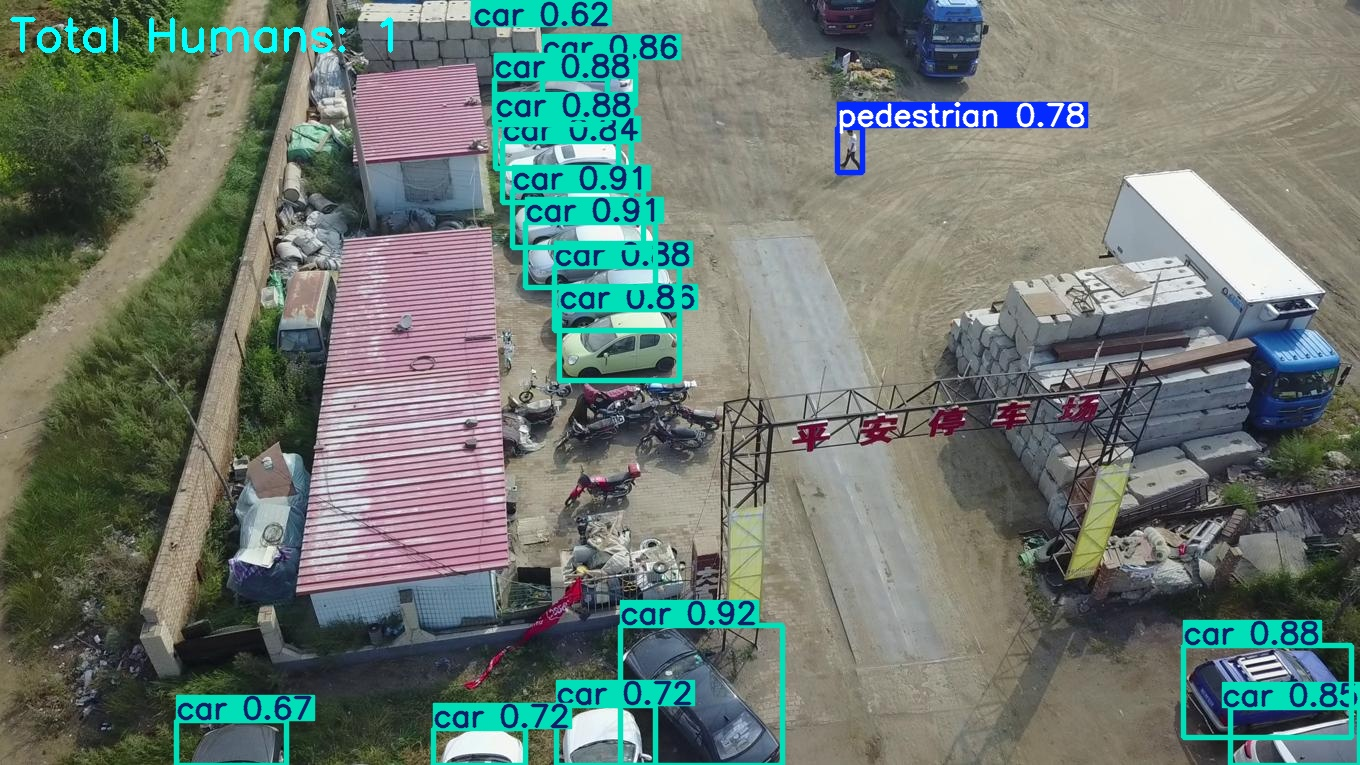

In [46]:
IPImage('/kaggle/working/result_3.jpg')

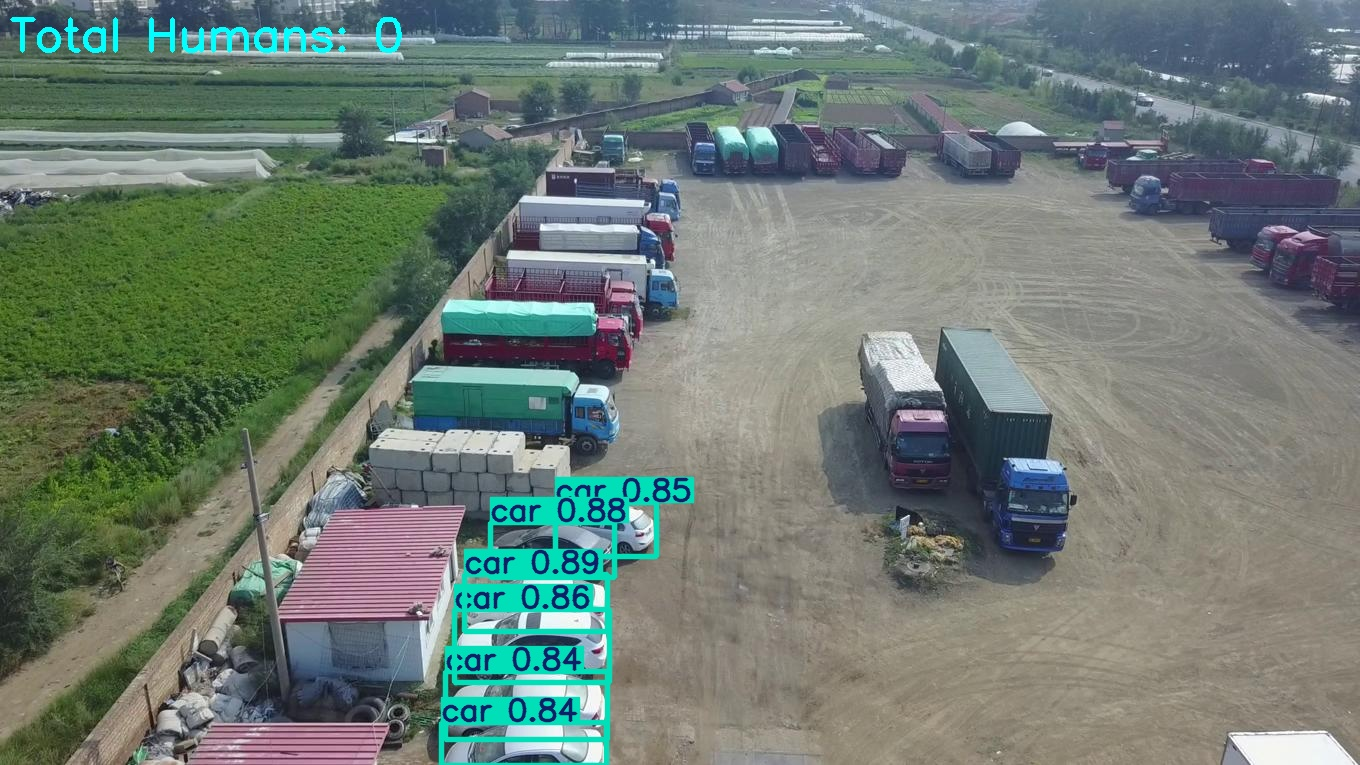

In [47]:
IPImage('/kaggle/working/result_4.jpg')

### The dataset doesnt contain any video, so I tried to use same type of pics one after another to implement the tracking first (Although, it didn't really work well, so later I downloaded an external video)

In [74]:
import cv2
import glob

raw_test_pool = glob.glob('/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/images/*.jpg')
track_seq = sorted([img for img in raw_test_pool if "0000001_" in img])[:60]

if len(track_seq) == 0:
    track_seq = sorted(raw_test_pool)[:60]

print(f"Found {len(track_seq)} frames")

CANVAS_W, CANVAS_H = 1280, 720
vid_out_path = '/kaggle/working/pics_tracking_output.avi'
vid_encoder = cv2.VideoWriter(vid_out_path, cv2.VideoWriter_fourcc(*'XVID'), 7, (CANVAS_W, CANVAS_H))

for frame_idx, img_path in enumerate(track_seq):
    results = model.track(source=img_path, classes=[0, 1, 3], tracker="bytetrack.yaml", persist=True, verbose=False)
    
    for r in results:
        frame = r.plot()
        if r.boxes is not None and len(r.boxes) > 0:
            class_ids = r.boxes.cls.int().tolist()
            human_count = class_ids.count(0) + class_ids.count(1)
            car_count = class_ids.count(3)
        else:
            human_count, car_count = 0, 0
            
        cv2.putText(frame, f'Humans: {human_count}', (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 4)
        cv2.putText(frame, f'Cars: {car_count}', (30, 120), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 255), 4)
        vid_encoder.write(cv2.resize(frame, (CANVAS_W, CANVAS_H)))
    
    if frame_idx % 10 == 0:
        print(f"Frame {frame_idx}/{len(track_seq)} done")

vid_encoder.release()
print("Done!")

Found 60 frames
Frame 0/60 done
Frame 10/60 done
Frame 20/60 done
Frame 30/60 done
Frame 40/60 done
Frame 50/60 done
Done!


In [75]:
from IPython.display import FileLink
FileLink(r'pics_tracking_output.avi')

/kaggle/working/pics_tracking_output.avi

### This generated video has some issues, it can't really keep up with tracking the same object as in each frame the camera angle chanegs significantly

### So, two other drone-view videos (that are actually videos, not still pics one after another) were downloaded and then tracking was tried

In [61]:
#checking if it is uploaded properly
import glob
files = glob.glob('/kaggle/input/**/*.mp4', recursive=True)
print(files)

['/kaggle/input/datasets/mumtahinaaaaa/drone-vid2/my_uploaded_drone2.mp4', '/kaggle/input/datasets/mumtahinaaaaa/drone-vid/my_uploaded_drone.mp4']


In [72]:
import cv2

input_video = '/kaggle/input/datasets/mumtahinaaaaa/drone-vid/my_uploaded_drone.mp4'
output_tracked_video = '/kaggle/working/real_drone_tracked.avi'

cap = cv2.VideoCapture(input_video)
original_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
original_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
original_fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"Video: {original_width}x{original_height} @ {original_fps}FPS, {total_frames} frames")

out_writer = cv2.VideoWriter(output_tracked_video, cv2.VideoWriter_fourcc(*'XVID'), original_fps, (original_width, original_height))

results_generator = model.track(
    source=input_video,
    classes=[0, 1, 3],
    tracker="bytetrack.yaml",
    persist=True,
    stream=True,
    conf=0.25,
    verbose=False
)

for idx, r in enumerate(results_generator):
    annotated_frame = r.plot()
    
    if r.boxes is not None and len(r.boxes) > 0:
        class_ids = r.boxes.cls.int().tolist()
        human_count = class_ids.count(0) + class_ids.count(1)
        car_count = class_ids.count(3)
    else:
        human_count, car_count = 0, 0
    
    cv2.putText(annotated_frame, f'Humans: {human_count}', (40, 70), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 4)
    cv2.putText(annotated_frame, f'Cars: {car_count}', (40, 140), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 255), 4)
    
    out_writer.write(annotated_frame)
    
    if idx % 30 == 0:
        print(f"Frame {idx}/{total_frames} done")

out_writer.release()
print("Done!")

Video: 1920x1080 @ 25FPS, 125 frames
Frame 0/125 done
Frame 30/125 done
Frame 60/125 done
Frame 90/125 done
Frame 120/125 done
Done!


In [73]:
from IPython.display import FileLink
FileLink(r'real_drone_tracked.avi')


/kaggle/working/real_drone_tracked.avi

In [70]:
import cv2

input_video = '/kaggle/input/datasets/mumtahinaaaaa/drone-vid2/my_uploaded_drone2.mp4'
output_tracked_video = '/kaggle/working/real_drone_tracked2.avi'

cap = cv2.VideoCapture(input_video)
original_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
original_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
original_fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"Video: {original_width}x{original_height} @ {original_fps}FPS, {total_frames} frames")

out_writer = cv2.VideoWriter(output_tracked_video, cv2.VideoWriter_fourcc(*'XVID'), original_fps, (original_width, original_height))

results_generator = model.track(
    source=input_video,
    classes=[0, 1, 3],
    tracker="bytetrack.yaml",
    persist=True,
    stream=True,
    conf=0.25,
    verbose=False
)

for idx, r in enumerate(results_generator):
    annotated_frame = r.plot()
    
    if r.boxes is not None and len(r.boxes) > 0:
        class_ids = r.boxes.cls.int().tolist()
        human_count = class_ids.count(0) + class_ids.count(1)
        car_count = class_ids.count(3)
    else:
        human_count, car_count = 0, 0
    
    cv2.putText(annotated_frame, f'Humans: {human_count}', (40, 70), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 4)
    cv2.putText(annotated_frame, f'Cars: {car_count}', (40, 140), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 255), 4)
    
    out_writer.write(annotated_frame)
    
    if idx % 30 == 0:
        print(f"Frame {idx}/{total_frames} done")

out_writer.release()
print("Done!")

Video: 2160x3840 @ 25FPS, 175 frames
Frame 0/175 done
Frame 30/175 done
Frame 60/175 done
Frame 90/175 done
Frame 120/175 done
Frame 150/175 done
Done!


In [71]:
from IPython.display import FileLink
FileLink(r'real_drone_tracked2.avi')

/kaggle/working/real_drone_tracked2.avi

### Checking if botsort gives better results:

In [77]:
import cv2

input_video = '/kaggle/input/datasets/mumtahinaaaaa/drone-vid2/my_uploaded_drone2.mp4'
output_tracked_video = '/kaggle/working/real_drone_tracked2b.avi'

cap = cv2.VideoCapture(input_video)
original_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
original_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
original_fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"Video: {original_width}x{original_height} @ {original_fps}FPS, {total_frames} frames")

out_writer = cv2.VideoWriter(output_tracked_video, cv2.VideoWriter_fourcc(*'XVID'), original_fps, (original_width, original_height))

results_generator = model.track(
    source=input_video,
    classes=[0, 1, 3],
    tracker="botsort.yaml",
    persist=True,
    stream=True,
    conf=0.25,
    verbose=False
)

for idx, r in enumerate(results_generator):
    annotated_frame = r.plot()
    
    if r.boxes is not None and len(r.boxes) > 0:
        class_ids = r.boxes.cls.int().tolist()
        human_count = class_ids.count(0) + class_ids.count(1)
        car_count = class_ids.count(3)
    else:
        human_count, car_count = 0, 0
    
    cv2.putText(annotated_frame, f'Humans: {human_count}', (40, 70), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 4)
    cv2.putText(annotated_frame, f'Cars: {car_count}', (40, 140), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 255), 4)
    
    out_writer.write(annotated_frame)
    
    if idx % 30 == 0:
        print(f"Frame {idx}/{total_frames} done")

out_writer.release()
print("Done!")

Video: 2160x3840 @ 25FPS, 175 frames
Frame 0/175 done
Frame 30/175 done
Frame 60/175 done
Frame 90/175 done
Frame 120/175 done
Frame 150/175 done
Done!


In [78]:
from IPython.display import FileLink
FileLink(r'real_drone_tracked2b.avi')

/kaggle/working/real_drone_tracked2b.avi